# Brain Age Prediction using Transfer Learning

Predicting biological brain age from 3D MRI scans using deep learning ensemble model. Dataset contains 3,794 brain MRI scans with subject ages ranging from 18-85 years.

**Approach:** Transfer learning with EfficientNetB0, ResNet50, and DenseNet121 architectures using ImageNet pretrained weights, followed by two-phase training (frozen base + fine-tuning).

**Results:** 66.8% accuracy (±5 years prediction error on test set)

In [ ]:
# Kaggle notebook
print("Running on Kaggle")

Running on Kaggle


## Setup & Data Loading

In [ ]:
from huggingface_hub import snapshot_download
import pandas as pd
import os

dataset_dir = snapshot_download(
    repo_id="radiata-ai/brain-structure",
    repo_type="dataset",
    cache_dir="/kaggle/working/brain_structure_cache"
)

metadata = pd.read_csv(os.path.join(dataset_dir, "metadata.csv"))
print("Done! Samples:", len(metadata))

Fetching ... files: 0it [00:00, ?it/s]

Done! Samples: 3794


### Sample Visualization

Age: 66


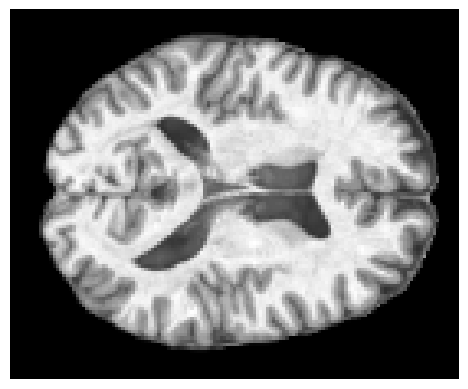

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import os

sample = metadata.iloc[0]
age = sample["age"]
print("Age:", age)

nii_path = os.path.join(dataset_dir, sample["t1_local_path"])
img = nib.load(nii_path)
data = img.get_fdata()

slice_img = data[:, :, data.shape[2] // 2]
plt.imshow(slice_img, cmap="gray")
plt.axis("off")
plt.show()

## Data Preprocessing: 3D to 2D Conversion

In [ ]:
import nibabel as nib
import numpy as np
import cv2
import os
import pandas as pd

metadata_path = os.path.join(dataset_dir, "metadata.csv")
metadata = pd.read_csv(metadata_path)
print(f"Total samples: {len(metadata)}")

images = []
ages = []

for _, row in metadata.iterrows():
    nii_path = os.path.join(dataset_dir, row["t1_local_path"])
    img = nib.load(nii_path)
    data = img.get_fdata()

    # Extract 5 slices from different brain depths and average
    z = data.shape[2]
    slices = [data[:, :, z // 5], data[:, :, 2 * z // 5], data[:, :, z // 2],
              data[:, :, 3 * z // 5], data[:, :, 4 * z // 5]]
    slice_img = np.mean(slices, axis=0)

    # Normalize to 0-1 range and resize
    slice_img = slice_img / np.max(slice_img)
    slice_img = cv2.resize(slice_img, (128, 128))
    images.append(slice_img)
    ages.append(row["age"])

X = np.squeeze(np.array(images))[..., np.newaxis]
y = np.array(ages)
print(f"Shape: {X.shape}, Age range: {y.min():.0f}-{y.max():.0f} years")

Total samples: 3794
Shape: (3794, 128, 128, 1), Age range: 6-98 years


## Split the dataset into train & validation


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

np.save("/kaggle/working/X_train.npy", X_train)
np.save("/kaggle/working/X_val.npy", X_val)
np.save("/kaggle/working/X_test.npy", X_test)
np.save("/kaggle/working/y_train.npy", y_train)
np.save("/kaggle/working/y_val.npy", y_val)
np.save("/kaggle/working/y_test.npy", y_test)

Train: (3035, 128, 128, 1) | Val: (379, 128, 128, 1) | Test: (380, 128, 128, 1)


### Load Preprocessed Splits

In [ ]:
import numpy as np

# Load splits from Kaggle working directory
X_train = np.load("/kaggle/working/X_train.npy")
X_val   = np.load("/kaggle/working/X_val.npy")
X_test  = np.load("/kaggle/working/X_test.npy")
y_train = np.load("/kaggle/working/y_train.npy")
y_val   = np.load("/kaggle/working/y_val.npy")
y_test  = np.load("/kaggle/working/y_test.npy")

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Age range: {y_train.min():.0f} - {y_train.max():.0f} years")

Train: (3035, 128, 128, 1) | Val: (379, 128, 128, 1) | Test: (380, 128, 128, 1)
Age range: 6 - 98 years


## Convert to 3-channel RGB (ImageNet compatibility)

In [ ]:
import numpy as np

X_train_rgb = np.concatenate([X_train * 255, X_train * 255, X_train * 255], axis=-1).astype(np.float32)
X_val_rgb = np.concatenate([X_val * 255, X_val * 255, X_val * 255], axis=-1).astype(np.float32)
X_test_rgb = np.concatenate([X_test * 255, X_test * 255, X_test * 255], axis=-1).astype(np.float32)

print(f"RGB shape: {X_train_rgb.shape}")

RGB shape: (3035, 128, 128, 3)


### Data Augmentation (Light)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    fill_mode='nearest'
)

## Model Architecture: Transfer Learning with EfficientNetB0

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

def build_efficientnet_model(input_shape=(128, 128, 3)):
    # Load pretrained ImageNet weights, remove original classification head
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False  # Freeze for initial training

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    
    # GlobalAveragePooling reduces feature maps to compact vector, fewer params = less overfitting
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)  # Regression: continuous age output
    
    model = tf.keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_efficientnet_model()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Training Strategy

### Phase 1: Initial Training (Frozen Base)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Phase 1: Train custom head only (base model frozen)
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
print("Phase 1: Training head (base frozen)...")
history1 = model.fit(
    X_train_rgb, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks
)

Phase 1: Training head (base frozen)...
Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 1082.2599 - mae: 26.3636
Epoch 1: val_loss improved from inf to 350.98676, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 247ms/step - loss: 1078.0907 - mae: 26.3114 - val_loss: 350.9868 - val_mae: 15.7204 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 381.8531 - mae: 16.3941
Epoch 2: val_loss improved from 350.98676 to 231.51892, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 381.3372 - mae: 16.3803 - val_loss: 231.5189 - val_mae: 12.3443 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 281.1281 - mae: 13.7783
Epoch 3: val_loss improved from 231.51892 to 192.07883, saving model to /kaggle/working/best_model.keras
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 280.9305 - mae: 13.7725 - val_loss: 192.0788 - val_mae: 11.1459 - learning_ra

### Phase 2: Fine-tuning (Unfrozen Layers)

In [ ]:
# Phase 2: Fine-tune base model with unfrozen layers
base_model.trainable = True
for layer in base_model.layers[:-45]:  # Keep only last 45 layers unfrozen
    layer.trainable = False

model.compile(optimizer=Adam(1.2e-4), loss='mse', metrics=['mae'])  # Lower LR for careful tuning
print("Phase 2: Fine-tuning last 45 layers...")

callbacks_extended = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history2 = model.fit(
    X_train_rgb, y_train,
    epochs=100,
    batch_size=10,
    validation_data=(X_val_rgb, y_val),
    callbacks=callbacks_extended
)

Phase 2: Fine-tuning last 45 layers...
Epoch 1/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 51.8434 - mae: 5.3999
Epoch 1: val_loss improved from inf to 103.44228, saving model to /kaggle/working/best_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 73s 134ms/step - loss: 51.8518 - mae: 5.4004 - val_loss: 103.4423 - val_mae: 7.6505 - learning_rate: 1.2000e-04
Epoch 2/100
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 62.6751 - mae: 5.9769
Epoch 2: val_loss improved from 103.44228 to 75.76208, saving model to /kaggle/working/best_model.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 62.6628 - mae: 5.9763 - val_loss: 75.7621 - val_mae: 6.6384 - learning_rate: 1.2000e-04
Epoch 3/100
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 62.8369 - mae: 5.9329
Epoch 3: val_loss did not improve from 75.76208
304/304 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 62.8213 - mae: 5.9323 - val_loss: 91.2284 - val_mae: 6.9942 - learning_rate: 1.2000e-04
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 

## Ensemble Learning: Multi-Architecture Approach

Train three different architectures to capture complementary features and combine predictions for improved robustness.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, ResNet50, DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import numpy as np

# Train 3 different architectures and combine predictions
architectures = [('EfficientNetB0', EfficientNetB0), ('ResNet50', ResNet50), ('DenseNet121', DenseNet121)]
ensemble_models = []

for arch_num, (arch_name, base_architecture) in enumerate(architectures, 1):
    print(f"Training {arch_num}/3: {arch_name}")
    
    # Different seeds for diversity
    np.random.seed(42 * arch_num)
    tf.random.set_seed(42 * arch_num)
    
    # Build model with different architecture
    base_model = base_architecture(include_top=False, weights="imagenet", input_shape=(128, 128, 3))
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=(128, 128, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    
    # Phase 1
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    callbacks_p1 = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0)
    ]
    model.fit(X_train_rgb, y_train, epochs=10, batch_size=32, validation_data=(X_val_rgb, y_val), callbacks=callbacks_p1, verbose=0)
    
    # Phase 2
    base_model.trainable = True
    for layer in base_model.layers[:-45]:
        layer.trainable = False
    
    model.compile(optimizer=Adam(1.2e-4), loss='mse', metrics=['mae'])
    callbacks_p2 = [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0),
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
        ModelCheckpoint(f'/kaggle/working/model_{arch_name}_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
    ]
    model.fit(X_train_rgb, y_train, epochs=100, batch_size=10, validation_data=(X_val_rgb, y_val), callbacks=callbacks_p2, verbose=0)
    
    best_model = tf.keras.models.load_model(f'/kaggle/working/model_{arch_name}_best.keras')
    ensemble_models.append((arch_name, best_model))
    print(f"✓ {arch_name}")

Training 1/3: EfficientNetB0
✓ EfficientNetB0
Training 2/3: ResNet50
✓ ResNet50
Training 3/3: DenseNet121
✓ DenseNet121


## Evaluation & Results

MAE: 4.72 yrs | RMSE: 6.71 yrs | R²: 0.9229
Accuracy (±5 yrs): 66.6%


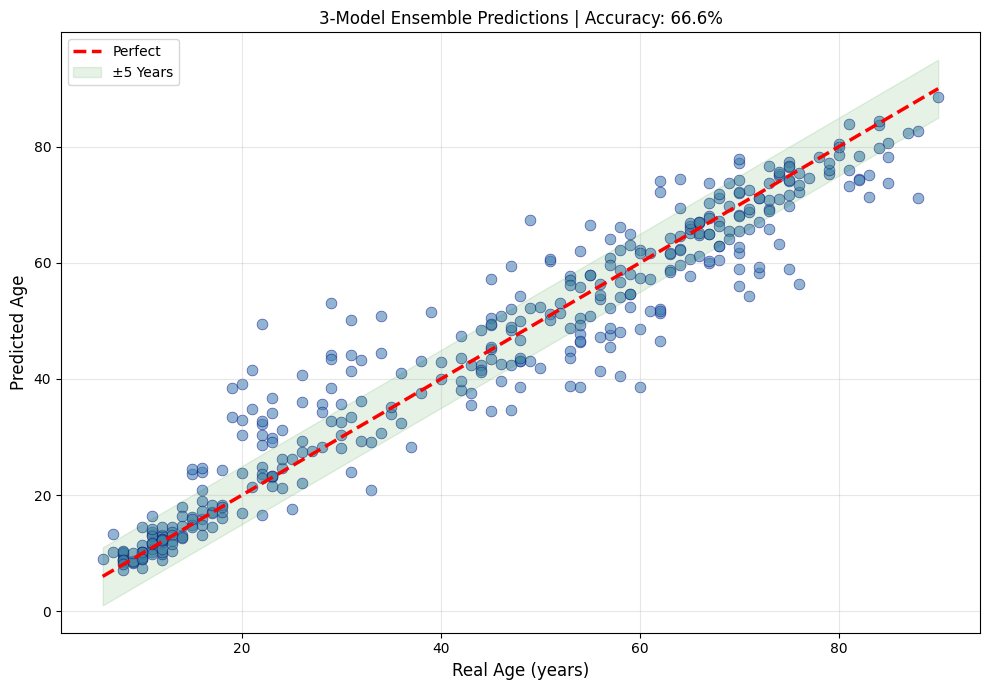

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load trained models and generate predictions
arch_names = ['EfficientNetB0', 'ResNet50', 'DenseNet121']
predictions_list = []

for arch_name in arch_names:
    model = load_model(f'/kaggle/working/model_{arch_name}_best.keras')
    y_pred_i = model.predict(X_test_rgb, verbose=0).flatten()
    predictions_list.append(y_pred_i)

# Ensemble: average predictions from all models
y_pred_final = np.mean(predictions_list, axis=0)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)
accuracy = np.mean(np.abs(y_test - y_pred_final) <= 5) * 100

print(f"MAE: {mae:.2f} yrs | RMSE: {rmse:.2f} yrs | R²: {r2:.4f}")
print(f"Accuracy (±5 yrs): {accuracy:.1f}%")

# Visualization
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_final, alpha=0.6, s=60, color='steelblue', edgecolors='navy', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5, label='Perfect')
plt.fill_between([y_test.min(), y_test.max()], [y_test.min()-5, y_test.max()-5],
                  [y_test.min()+5, y_test.max()+5], alpha=0.1, color='green', label='±5 Years')
plt.xlabel("Real Age (years)", fontsize=12)
plt.ylabel("Predicted Age", fontsize=12)
plt.title(f"3-Model Ensemble Predictions | Accuracy: {accuracy:.1f}%", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()